In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
ethiopia["country"] = "Ethiopia"

kenya = pd.read_csv("../data/kenya_clean.csv")
kenya["country"] = "Kenya"

tanzania = pd.read_csv("../data/tanzania_clean.csv")
tanzania["country"] = "Tanzania"

sudan = pd.read_csv("../data/sudan_clean.csv")
sudan["country"] = "Sudan"

nigeria = pd.read_csv("../data/nigeria_clean.csv")
nigeria["country"] = "Nigeria"
# Load and combine all datasets

combined_df = pd.concat([ethiopia,kenya,tanzania,sudan,nigeria], ignore_index=True)


     T2M  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  WS2M  WS2M_MAX        YEAR  \
0  11.73    22.75     3.44          0.0  41.79  2.73      5.07  2015-01-01   
1  12.30    24.01     4.09          0.0  33.29  2.39      4.19  2015-01-02   
2  12.49    24.17     3.97          0.0  33.83  1.77      2.76  2015-01-03   
3  14.08    23.78     6.90          0.0  38.84  0.87      1.28  2015-01-04   
4  14.06    23.15     7.32          0.0  47.07  1.34      2.14  2015-01-05   

    country  
0  Ethiopia  
1  Ethiopia  
2  Ethiopia  
3  Ethiopia  
4  Ethiopia  
(20540, 9)


,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,YEAR,country
0,11.73,22.75,3.44,0.00,41.79,2.73,5.07,2015-01-01,Ethiopia
1,12.30,24.01,4.09,0.00,33.29,2.39,4.19,2015-01-02,Ethiopia
2,12.49,24.17,3.97,0.00,33.83,1.77,2.76,2015-01-03,Ethiopia
3,14.08,23.78,6.90,0.00,38.84,0.87,1.28,2015-01-04,Ethiopia
4,14.06,23.15,7.32,0.00,47.07,1.34,2.14,2015-01-05,Ethiopia
...,...,...,...,...,...,...,...,...,...
20535,29.05,32.43,26.69,2.82,76.60,2.35,3.39,2026-03-27,Nigeria
20536,28.72,31.98,27.14,5.19,79.61,2.55,3.17,2026-03-28,Nigeria
20537,27.72,29.53,26.21,1.43,82.83,1.10,1.78,2026-03-29,Nigeria
20538,28.42,31.17,26.36,0.85,77.73,2.30,3.40,2026-03-30,Nigeria


# Temperature Trend Comparison

In [34]:
# Convert YEAR column to datetime
combined_df['YEAR'] = pd.to_datetime(combined_df['YEAR'])

# Create Year-Month column
combined_df['year_month'] = combined_df['YEAR'].dt.to_period('M')

# Monthly average T2M by country
monthly_t2m = (
    combined_df
    .groupby(['year_month', 'country'])['T2M']
    .mean()
    .reset_index()
)
# Convert period back to timestamp for plotting
monthly_t2m['year_month'] = monthly_t2m['year_month'].dt.to_timestamp()


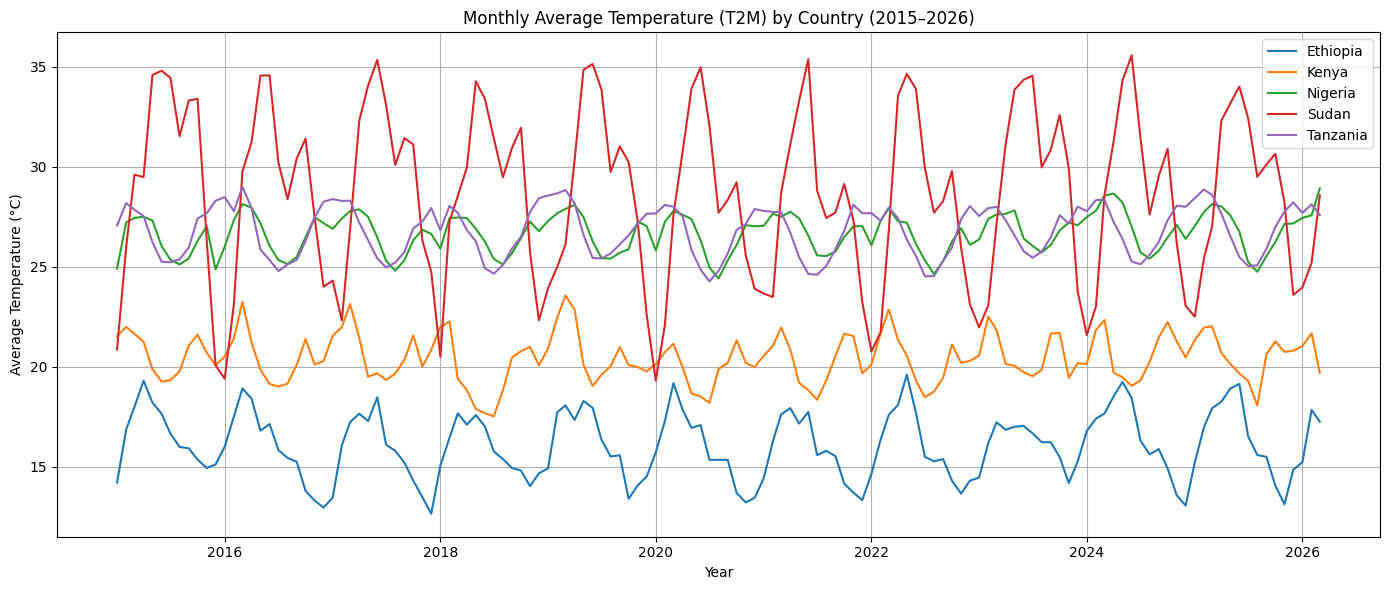

In [35]:

# Plot
plt.figure(figsize=(14,6))

for country in monthly_t2m['country'].unique():
    country_data = monthly_t2m[monthly_t2m['country'] == country]
    plt.plot(
        country_data['year_month'],
        country_data['T2M'],
        label=country
    )

plt.title('Monthly Average Temperature (T2M) by Country (2015–2026)')
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Precipitation Variability Comparison

In [36]:
# Summary statistics for T2M by country
summary_table = (
    combined_df
    .groupby('country')['T2M']
    .agg(
        Mean='mean',
        Median='median',
        Std_Dev='std'
    )
    .round(2)
)

print(summary_table)

           Mean  Median  Std_Dev
country                         
Ethiopia  16.07   16.04     1.90
Kenya     20.43   20.36     1.44
Nigeria   26.66   26.82     1.12
Sudan     28.76   29.16     4.68
Tanzania  26.80   26.99     1.33


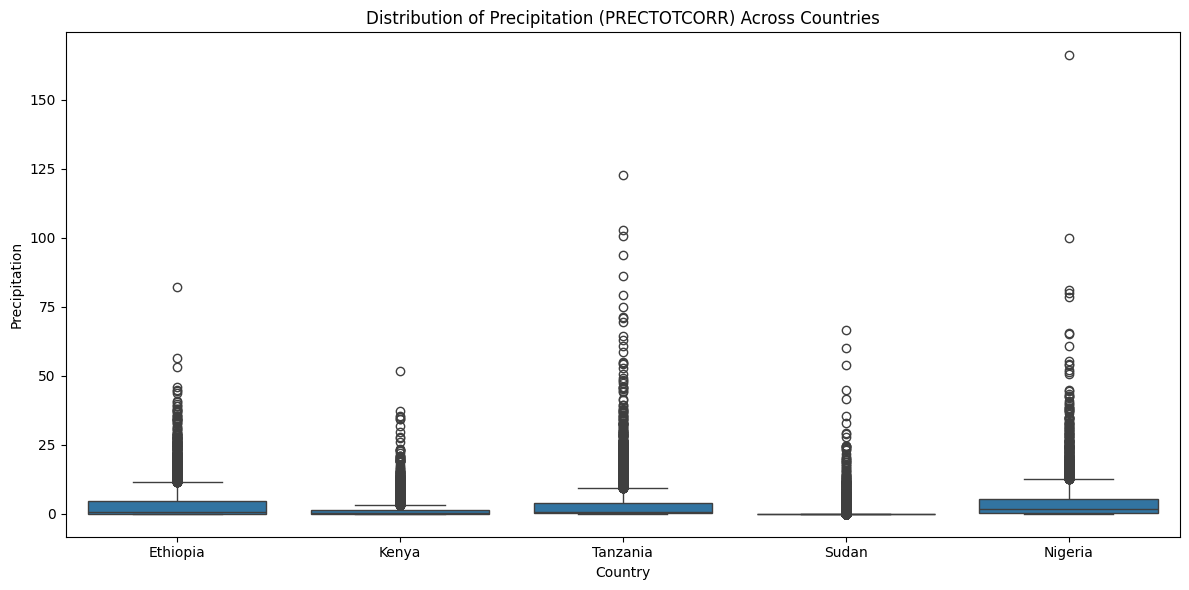

In [37]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=combined_df,
    x='country',
    y='PRECTOTCORR'
)

plt.title('Distribution of Precipitation (PRECTOTCORR) Across Countries')
plt.xlabel('Country')
plt.ylabel('Precipitation')
plt.tight_layout()
plt.show()

In [38]:
# Summary statistics for precipitation by country
precip_summary = (
    combined_df
    .groupby('country')['PRECTOTCORR']
    .agg(
        Mean='mean',
        Median='median',
        Std_Dev='std'
    )
    .round(2)
)

print(precip_summary.to_markdown())

| country   |   Mean |   Median |   Std_Dev |
|:----------|-------:|---------:|----------:|
| Ethiopia  |   3.63 |     0.82 |      6.29 |
| Kenya     |   1.47 |     0.38 |      3.18 |
| Nigeria   |   4.21 |     1.84 |      7.27 |
| Sudan     |   0.64 |     0    |      3.06 |
| Tanzania  |   3.74 |     0.64 |      8    |


# Extreme Event Frequency

In [45]:
# Ensure date column is datetime
combined_df['YEAR'] = pd.to_datetime(combined_df['YEAR'])
# print(combined_df)
# Extract year
combined_df['year'] = combined_df['YEAR'].dt.year

# Filter extreme heat days and count by country/year
extreme_heat_days = (
    combined_df[combined_df['T2M_MAX'] > 35]
    .groupby(['country', 'year'])
    .size()
    .reset_index(name='extreme_heat_days')
)

print(extreme_heat_days)
# print(combined_df)

   country  year  extreme_heat_days
0    Sudan  2015                280
1    Sudan  2016                252
2    Sudan  2017                266
3    Sudan  2018                248
4    Sudan  2019                251
5    Sudan  2020                195
6    Sudan  2021                212
7    Sudan  2022                202
8    Sudan  2023                262
9    Sudan  2024                223
10   Sudan  2025                260
11   Sudan  2026                 43


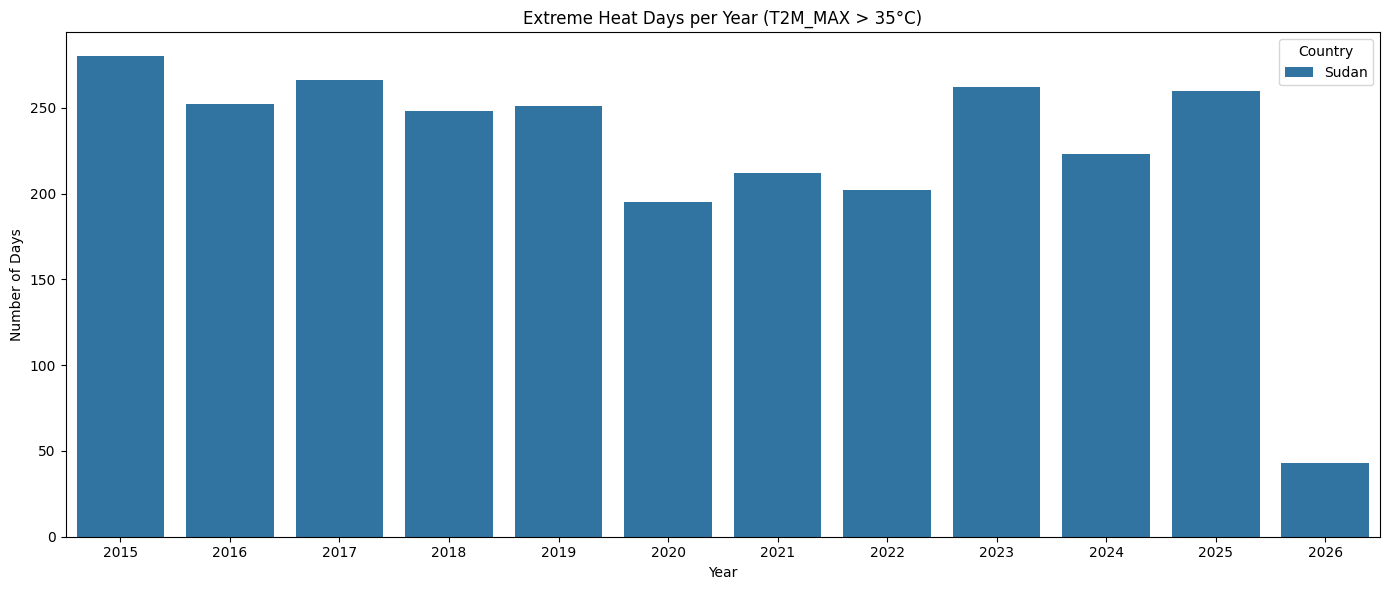

In [51]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=extreme_heat_days,
    x='year',
    y='extreme_heat_days',
    hue='country'
)

plt.title('Extreme Heat Days per Year (T2M_MAX > 35°C)')
plt.xlabel('Year')
plt.ylabel('Number of Days')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

In [53]:
# Ensure date column is datetime
combined_df['YEAR'] = pd.to_datetime(combined_df['YEAR'])

# Sort data
combined_df = combined_df.sort_values(['country', 'YEAR'])

# Dry day flag
combined_df['dry_day'] = combined_df['PRECTOTCORR'] < 1

# Function to find longest consecutive dry spell
def longest_dry_streak(group):
    # Create groups when dry/wet status changes
    streak_groups = (group['dry_day'] != group['dry_day'].shift()).cumsum()
    
    # Count consecutive dry-day streaks only
    dry_streaks = (
        group[group['dry_day']]
        .groupby(streak_groups)
        .size()
    )
    
    return dry_streaks.max() if not dry_streaks.empty else 0

# Extract year
combined_df['year'] = combined_df['YEAR'].dt.year

# Calculate longest dry spell per country per year
dry_spell_summary = (
    combined_df
    .groupby(['country', 'year'])
    .apply(longest_dry_streak)
    .reset_index(name='max_consecutive_dry_days')
)

# print(dry_spell_summary)

C:\Users\bemnet\AppData\Local\Temp\ipykernel_22564\1719165726.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(longest_dry_streak)


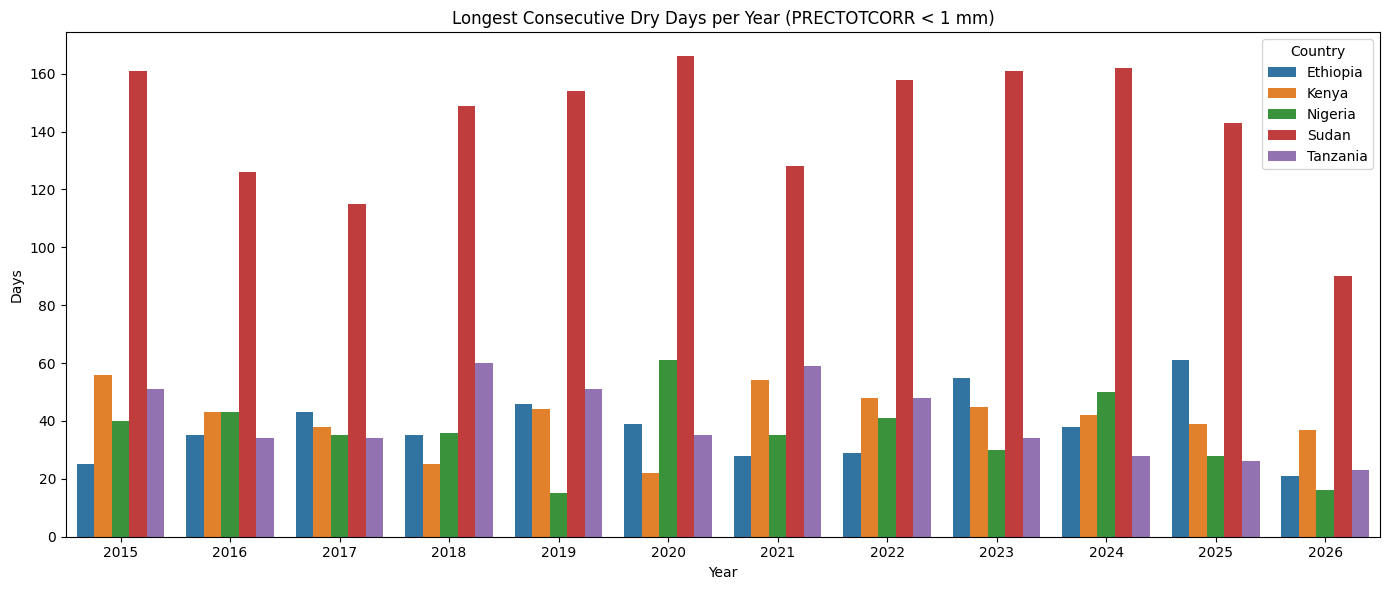

In [52]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=dry_spell_summary,
    x='year',
    y='max_consecutive_dry_days',
    hue='country'
)

plt.title('Longest Consecutive Dry Days per Year (PRECTOTCORR < 1 mm)')
plt.xlabel('Year')
plt.ylabel('Days')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

In [ ]:
heat_risk = (
    extreme_heat_days
    .groupby('country')['extreme_heat_days']
    .mean()
    .rename('Avg_Extreme_Heat_Days')
)

# Average longest dry spell per country
dry_risk = (
    dry_spell_summary
    .groupby('country')['max_consecutive_dry_days']
    .mean()
    .rename('Avg_Max_Dry_Spell')
)

# Temperature stats
temp_stats = (
    combined_df.groupby('country')['T2M']
    .agg(
        Mean_T2M='mean',
        Temp_SD='std'
    )
)

# Precipitation variability
precip_stats = (
    combined_df.groupby('country')['PRECTOTCORR']
    .agg(
        Precip_SD='std'
    )
)

# Combine all indicators
vulnerability = (
    temp_stats
    .join(precip_stats)
    .join(heat_risk)
    .join(dry_risk)
)
vulnerability = vulnerability.fillna(0)
# Simple ranking score
vulnerability['Vulnerability_Score'] = (
      vulnerability['Mean_T2M'].rank(ascending=False)
    + vulnerability['Precip_SD'].rank(ascending=False)
    + vulnerability['Avg_Extreme_Heat_Days'].rank(ascending=False)
    + vulnerability['Avg_Max_Dry_Spell'].rank(ascending=False)
)

# Rank countries
vulnerability = vulnerability.sort_values(
    'Vulnerability_Score',
    ascending=False
)

# Add final rank
vulnerability['Climate_Vulnerability_Rank'] = range(
    1,
    len(vulnerability)+1
)
# print(extreme_heat_days)
print(vulnerability.round(2))

   country  year  extreme_heat_days
0    Sudan  2015                280
1    Sudan  2016                252
2    Sudan  2017                266
3    Sudan  2018                248
4    Sudan  2019                251
5    Sudan  2020                195
6    Sudan  2021                212
7    Sudan  2022                202
8    Sudan  2023                262
9    Sudan  2024                223
10   Sudan  2025                260
11   Sudan  2026                 43
          Mean_T2M  Temp_SD  Precip_SD  Avg_Extreme_Heat_Days  \
country                                                         
Ethiopia     16.07     1.90       6.29                    0.0   
Kenya        20.43     1.44       3.18                    0.0   
Nigeria      26.66     1.12       7.27                    0.0   
Tanzania     26.80     1.33       8.00                    0.0   
Sudan        28.76     4.68       3.06                  224.5   

          Avg_Max_Dry_Spell  Vulnerability_Score  Climate_Vulnerability_Rank

## Climate Vulnerability Insights for COP32 (Policy Brief)

* Sudan shows the highest mean temperature (**28.76°C**) and the largest temperature variability (**Temp_SD = 4.68**), indicating both extreme heat levels and fluctuations. This suggests an already hot climate that is becoming more volatile, pointing toward intensified heat stress and increasing risks to human health, agriculture, and water systems.

* Tanzania (**Precip_SD = 8.00**) and Nigeria (**Precip_SD = 7.27**) exhibit the highest precipitation variability, signaling highly unstable rainfall patterns. This level of variability increases the likelihood of both floods and droughts, making water resource management and agricultural planning more difficult.

* Sudan stands out with an exceptionally high number of extreme heat days (**224.5 days/year**) and very long dry spells (**142.75 days**), indicating severe and persistent climate stress. This combination reflects chronic exposure to extreme conditions, making Sudan highly vulnerable to desertification, water scarcity, and food insecurity.

* Ethiopia has the lowest mean temperature (**16.07°C**) and no recorded extreme heat days, suggesting relatively lower heat stress. However, its precipitation variability (**6.29**) is still significant, and dry spells (**~38 days**) indicate moderate drought exposure. Compared to neighbors, Ethiopia is less exposed to extreme heat but still faces meaningful rainfall instability risks.

* Ethiopia should prioritize **Sudan** for climate finance advocacy. The data shows Sudan experiences the most extreme combination of risks: highest temperatures, greatest temperature variability, longest dry spells, and overwhelming extreme heat frequency. These indicators collectively point to severe climate vulnerability, justifying urgent adaptation and resilience funding.
